# Fidelity, utility and cost analysis

Reads the pre-computed tables in `evaluation/results/` and plots them. Does **not** recompute
anything: run `sdg/generate_runs.py`, `sdg/generate_smartnoise.py`, `evaluation/eval_fidelity.py`
and `evaluation/eval_utility.py` first. Privacy lives in `benchmark_tapas/privacy_analysis.ipynb`.

| Section | Reads | Paper |
|---|---|---|
| Fidelity | `fidelity_summary.csv` | Table 2 (left), `figures/fidelity_comparison.png` |
| Utility | `utility_summary.csv` | Table 2 (right), `figures/utility_metric_comparison.png` |
| Neural convergence | `benchmark_tapas/results/convergence/` | Appendix A.2, Table 4 |
| Computational cost | `computational_cost.csv` | Appendix B.4, Table 9 |

Six generators at ε = 1.0, 5 seeds each: BN, PrivBayes, CTGAN, DPGAN (Synthcity) and AIM, DP-CTGAN
(SmartNoise). PrivBayes and DPGAN are under investigation (paper Appendix A.3) and are not in the
main-text results.

## Load results

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

RESULTS = Path('results')            # evaluation/results/
FIGS = RESULTS / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)


# Repo palette (from the reference chart): orange + grey primary, teal + pink accent.
ORANGE, GREY, TEAL, PINK = "#CE4E36", "#3A3A3A", "#8CA9A0", "#D2B4B1"
# 5th and 6th slots for the two SmartNoise generators - the 4-colour palette had no
# free step. Slate blue and ochre are separable from all four and from each other, and
# neither is the limiting pair (see palette note below).
SLATE = "#6B7F99"
OCHRE = "#A8763E"

METHOD_ORDER  = ['bayesian_network', 'privbayes', 'ctgan', 'dpgan', 'aim', 'dpctgan']
METHOD_LABELS = {
    'bayesian_network': 'BN',
    'privbayes':        'PrivBayes',
    'ctgan':            'CTGAN',
    'dpgan':            'DPGAN',
    'aim':              'AIM',
    'dpctgan':          'DP-CTGAN',
}
COLORS = {
    'bayesian_network': ORANGE,
    'privbayes':        GREY,
    'ctgan':            TEAL,
    'dpgan':            PINK,
    'aim':              SLATE,
    'dpctgan':          PINK,
}

# The two SmartNoise generators come from sdg/generate_smartnoise.py and are scored by
# the same evaluation/eval_{fidelity,utility}.py pass as the four Synthcity ones, on the
# same 5 seeds against the same held-out split -- so these bars are like-for-like.
#
# One caveat that belongs next to any DP comparison here: the three DP methods do NOT
# share a delta at eps=1.0. PrivBayes is pure DP (delta=0), AIM runs at delta=1e-9,
# synthcity's DPGAN derives delta=1/n=4.65e-5, and SmartNoise's DP-CTGAN derives
# delta=1/(n*sqrt(n))=3.17e-7. DP-CTGAN also OVERSHOOTS its budget: epsilon is a
# stopping rule there, and the generation log records 23 epochs spending eps=1.004
# against the 1.0 requested.

# Bar order for the fidelity and utility figures. NOT the same as METHOD_ORDER:
#   - synthcity's DPGAN is dropped from both charts; DP-CTGAN is the neural DP method
#     that gets shown. Its rows stay in util/sdm and in every table below, so nothing
#     is lost -- this controls the figures only.
#   - the order pairs each DP method with its non-DP counterpart within a family:
#     statistical first (BN no-DP, PrivBayes DP, AIM DP), then neural (CTGAN no-DP,
#     DP-CTGAN DP), so a reader compares like with like left to right.
PLOT_ORDER = ['bayesian_network', 'privbayes', 'aim', 'ctgan', 'dpctgan']

# Palette note: CTGAN (teal) vs DPGAN (pink) separate by only dE 10.8 in normal vision
# and 5.9 under protanopia, below the dE 15 / 8 floors. Every chart below also labels
# methods on the x-axis or directly, so identity is never colour-alone - that is the
# required relief. Worth re-stepping if these ever appear without labels.

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})


In [ ]:
# Utility + fidelity come from the in-house multi-run tables (mean +/- std over
# seeds.RUN_SEEDS): utility scored on the held-out test split, so memorisation is not
# rewarded. See evaluation/eval_utility.py and evaluation/eval_fidelity.py.
util_raw = pd.read_csv(RESULTS / 'utility_summary.csv')     # <- evaluation/eval_utility.py
fid_raw  = pd.read_csv(RESULTS / 'fidelity_summary.csv')    # <- evaluation/eval_fidelity.py

print('Utility (in-house):  ', util_raw.shape)
print('Fidelity (in-house): ', fid_raw.shape)

In [111]:
# Both summary tables are wide already: one row per method, a _mean and a _std per
# metric. Split each into a mean frame and a std frame, indexed by method label.
FIDELITY_STEMS = ['KSComplement', 'TVComplement',
                  'CorrelationSimilarity', 'ContingencySimilarity']
UTILITY_STEMS  = ['tstr_xgboost_auc', 'trtr_xgboost_auc', 'retention_xgboost',
                  'tstr_logistic_regression_auc', 'trtr_logistic_regression_auc',
                  'retention_logistic_regression']

def mean_std(raw, stems):
    d = raw.set_index('method').reindex(METHOD_ORDER)
    d.index = [METHOD_LABELS[m] for m in d.index]
    mean = pd.DataFrame({s: d[f'{s}_mean'] for s in stems if f'{s}_mean' in d}, index=d.index)
    sd   = pd.DataFrame({s: d[f'{s}_std']  for s in stems if f'{s}_std'  in d}, index=d.index)
    return mean, sd

# `sdm` keeps its old name so the fidelity cells below are unchanged; its columns are
# now run means rather than a single draw.
sdm, sdm_sd = mean_std(fid_raw, FIDELITY_STEMS)
util, util_sd = mean_std(util_raw, UTILITY_STEMS)
print('n runs per method:', util_raw.set_index('method')['n_runs'].to_dict())



n runs per method: {'bayesian_network': 5, 'privbayes': 5, 'ctgan': 5, 'dpgan': 5, 'aim': 5, 'dpctgan': 5}


In [112]:
# Utility, mean over runs. TSTR/TRTR are both AUC on the SAME 5,381-record holdout.
util.round(4)



,tstr_xgboost_auc,trtr_xgboost_auc,retention_xgboost,tstr_logistic_regression_auc,trtr_logistic_regression_auc,retention_logistic_regression
BN,0.7594,0.9274,0.8188,0.7561,0.902,0.8383
PrivBayes,0.8534,0.9274,0.9202,0.8379,0.902,0.9289
CTGAN,0.8626,0.9274,0.9301,0.8714,0.902,0.9660
DPGAN,0.5087,0.9274,0.5485,0.5585,0.902,0.6192
AIM,0.6800,0.9274,0.7333,0.7477,0.902,0.8289
DP-CTGAN,0.6492,0.9274,0.7000,0.6010,0.902,0.6663


In [113]:
# Fidelity, mean over runs (synthetic vs training data).
sdm.round(4)



,KSComplement,TVComplement,CorrelationSimilarity,ContingencySimilarity
BN,0.7274,0.8966,0.9702,0.7889
PrivBayes,0.8524,0.9445,0.9602,0.8911
CTGAN,0.6638,0.8713,0.9846,0.7717
DPGAN,0.2888,0.2480,0.9566,0.0864
AIM,0.9131,0.9876,0.7839,0.9425
DP-CTGAN,0.3591,0.7064,0.8890,0.5445


In [115]:
# Utility retention = TSTR / TRTR, both scored on the same 5,381-record holdout,
# so this is a like-for-like ratio. Computed in eval_utility.py; read back here
# with its across-run spread.
ret = pd.DataFrame({
    'retention_xgb':    util['retention_xgboost'],
    'retention_xgb_sd': util_sd['retention_xgboost'],
    'retention_lr':     util['retention_logistic_regression'],
    'retention_lr_sd':  util_sd['retention_logistic_regression'],
})
ret.round(4)



,retention_xgb,retention_xgb_sd,retention_lr,retention_lr_sd
BN,0.8188,0.0111,0.8383,0.0346
PrivBayes,0.9202,0.0540,0.9289,0.0496
CTGAN,0.9301,0.0057,0.9660,0.0046
DPGAN,0.5485,0.0993,0.6192,0.2112
AIM,0.7333,0.0292,0.8289,0.0234
DP-CTGAN,0.7000,0.1372,0.6663,0.0809


## Fidelity

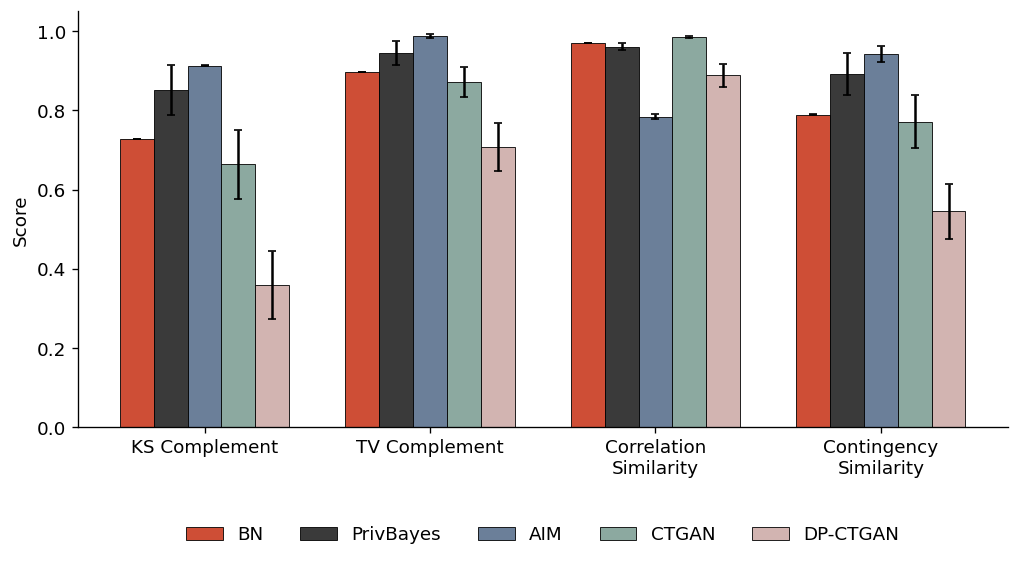

In [117]:
fidelity_metrics = ['KSComplement', 'TVComplement', 'CorrelationSimilarity', 'ContingencySimilarity']
fidelity_labels  = ['KS Complement', 'TV Complement',
                    'Correlation\nSimilarity', 'Contingency\nSimilarity']

x = np.arange(len(fidelity_metrics))
# The bars span 0.75 of the unit x-step, leaving a 0.25 gap between metric groups --
# the split is held at 0.75/0.25 whatever PLOT_ORDER's length is. Within a group the
# centre spacing equals the bar width, so bars stay flush and the comparison that
# matters -- method against method on one metric -- reads as a single block.
# The metric groups themselves are unchanged; only which methods appear, and in what
# order, comes from PLOT_ORDER.
width = 0.75 / len(PLOT_ORDER)
fig, ax = plt.subplots(figsize=(10, 4.5))

for i, method in enumerate(PLOT_ORDER):
    label = METHOD_LABELS[method]
    if label not in sdm.index or sdm.loc[label, fidelity_metrics].isna().all():
        continue                      # method not run yet (e.g. AIM, deferred)
    vals = [sdm.loc[label, m] for m in fidelity_metrics]
    errs = [sdm_sd.loc[label, m] for m in fidelity_metrics]
    off = (i - (len(PLOT_ORDER) - 1) / 2) * width
    ax.bar(x + off, vals, width, yerr=errs, capsize=2.5, label=label,
           color=COLORS[method], edgecolor='black', linewidth=0.5)

ax.set_xticks(x); ax.set_xticklabels(fidelity_labels)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
# ax.set_title('Fidelity vs training data — mean $\\pm$ s.d. over 5 runs')
ax.legend(frameon=False, ncol=5, loc='lower center', bbox_to_anchor=(0.5, -0.32))
ax.spines[['top', 'right']].set_visible(False)
plt.savefig(FIGS / 'fidelity_comparison.png', bbox_inches='tight', dpi=150)
plt.show()



## Utility retention (TSTR / TRTR)

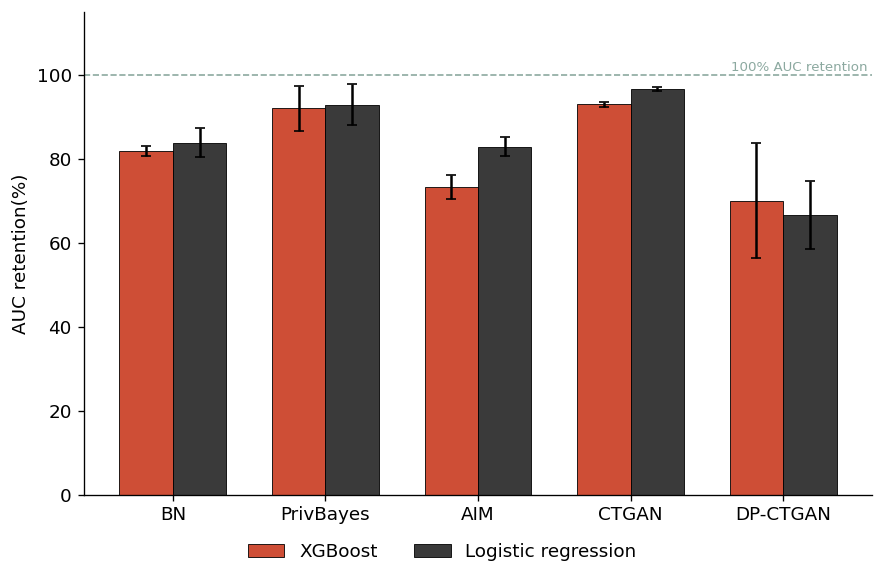

In [118]:
# Retention = TSTR / TRTR. The absolute-AUC panel this used to sit beside is dropped --
# retention already carries the TRTR ceiling (it IS the ceiling, rescaled to 100%), so
# nothing about the comparison is lost, only the redundant axis.
# Error bars are across-seed s.d. (seeds.RUN_SEEDS) - read them before comparing bars.
fig, ax = plt.subplots(figsize=(7.5, 4.6))

labels = [METHOD_LABELS[m] for m in PLOT_ORDER
          if not util.loc[METHOD_LABELS[m]].isna().all()]
methods_present = [m for m in PLOT_ORDER if METHOD_LABELS[m] in labels]
x = np.arange(len(labels))
width = 0.35

bars_xgb = ax.bar(x - width/2, [100 * util.loc[l, 'retention_xgboost'] for l in labels], width,
                  yerr=[100 * util_sd.loc[l, 'retention_xgboost'] for l in labels], capsize=3,
                  label='XGBoost', color=ORANGE, edgecolor='black', linewidth=0.5)
bars_lr = ax.bar(x + width/2, [100 * util.loc[l, 'retention_logistic_regression'] for l in labels], width,
                 yerr=[100 * util_sd.loc[l, 'retention_logistic_regression'] for l in labels], capsize=3,
                 label='Logistic regression', color=GREY, edgecolor='black', linewidth=0.5)
ax.axhline(100, ls='--', lw=1, color=TEAL)
ax.text(len(labels) - 0.45, 101, '100% AUC retention', fontsize=8, color=TEAL, ha='right')

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('AUC retention(%)')
ax.set_ylim(0, 115)
# ax.set_title('Utility retention — TSTR / TRTR')
ax.spines[['top', 'right']].set_visible(False)

fig.legend(handles=[bars_xgb, bars_lr], labels=['XGBoost', 'Logistic regression'],
          frameon=False, ncol=2, loc='lower center', bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.savefig(FIGS / 'utility_metric_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


## Neural convergence check — does `n_iter` need changing before the privacy audits?

`benchmark_tapas/` caps the GANs' `n_iter` during the TAPAS audits, because a single audit
re-fits the generator ~300 times. The cap is only defensible if the capped model has
**converged** — an undertrained GAN leaks less simply because it learned less, which reads
as privacy but isn't.

`benchmark_tapas/tuning/convergence_check.py` sweeps `n_iter` over 3 seeds each at
50/100/200 plus 1 seed at `default` (2000 with early stopping) as the converged ceiling,
scoring with the same leak-free TSTR used above. Read the **plateau**, not the peak: pick the
smallest `n_iter` whose mean is within noise of the ceiling, where noise is the across-seed
s.d. in this very table.


In [119]:
CONV = Path('../benchmark_tapas/results/convergence/convergence_check_tstr.csv')
if not CONV.exists():
    print('convergence_check_tstr.csv not found - run benchmark_tapas/tuning/convergence_check.py')
    conv = conv_summary = None
else:
    conv = pd.read_csv(CONV)
    conv['n_iter'] = conv['n_iter'].astype(str)
    ORDER = ['50', '100', '200', 'default']
    conv_summary = (conv.groupby(['method', 'n_iter'])
                        .agg(n_seeds=('seed', 'count'),
                             tstr_mean=('tstr_xgboost_auc', 'mean'),
                             tstr_sd=('tstr_xgboost_auc', 'std'),
                             retention_mean=('retention_xgboost', 'mean'),
                             fit_s=('fit_time_s', 'mean'),
                             gen_s=('generate_time_s', 'mean'))
                        .reset_index())
    conv_summary['_o'] = conv_summary['n_iter'].map({v: i for i, v in enumerate(ORDER)})
    conv_summary = conv_summary.sort_values(['method', '_o']).drop(columns='_o').reset_index(drop=True)
    display(conv_summary.round(4))



,method,n_iter,n_seeds,tstr_mean,tstr_sd,retention_mean,fit_s,gen_s
0,ctgan,50,3,0.8655,0.0043,0.9333,195.5900,0.1000
1,ctgan,100,3,0.8669,0.0064,0.9347,263.9533,0.0667
2,ctgan,200,3,0.8645,0.0057,0.9321,519.9400,0.0700
3,ctgan,default,1,0.8749,NaN,0.9434,1041.2000,0.0600
4,dpgan,50,3,0.4717,0.1033,0.5086,152.4900,0.1800
5,dpgan,100,3,0.4622,0.0532,0.4984,299.8167,0.1433
6,dpgan,200,3,0.4500,0.0246,0.4852,595.4033,0.1033
7,dpgan,default,1,0.6123,NaN,0.6602,1069.8100,0.0900


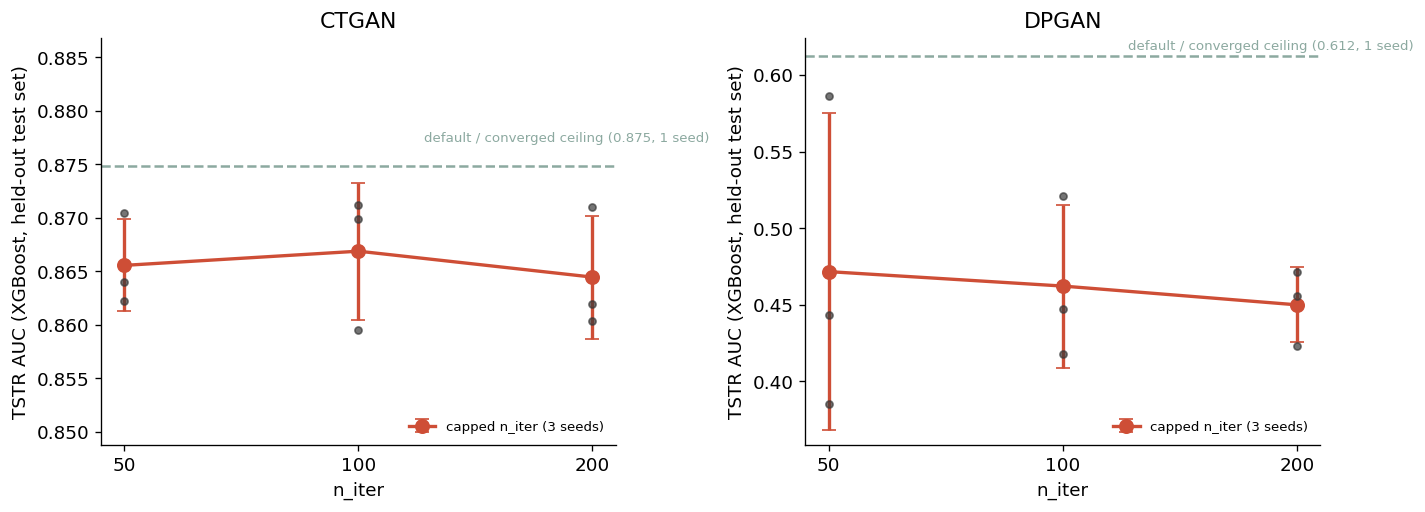

In [120]:
if conv is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=False)
    for ax, method in zip(axes, ['ctgan', 'dpgan']):
        s = conv_summary[conv_summary.method == method]
        caps = s[s.n_iter != 'default']
        ceil = s[s.n_iter == 'default']

        xs = np.arange(len(caps))
        ax.errorbar(xs, caps.tstr_mean, yerr=caps.tstr_sd, fmt='-o', color=ORANGE,
                    capsize=4, lw=2, ms=8, label='capped n_iter (3 seeds)')
        # individual draws, so the spread is visible rather than just summarised
        for xi, n in zip(xs, caps.n_iter):
            pts = conv[(conv.method == method) & (conv.n_iter == n)]['tstr_xgboost_auc']
            ax.scatter([xi] * len(pts), pts, color=GREY, s=18, zorder=3, alpha=0.7)

        if len(ceil):
            c = float(ceil.tstr_mean.iloc[0])
            ax.axhline(c, ls='--', lw=1.5, color=TEAL)
            # headroom above the ceiling so the label sits inside the axes
            lo = min(float((caps.tstr_mean - caps.tstr_sd.fillna(0)).min()), c)
            ax.set_ylim(lo - 0.01, c + 0.012)
            ax.text(len(caps) - 0.5, c + 0.002, f'default / converged ceiling ({c:.3f}, 1 seed)',
                    fontsize=8, color=TEAL, ha='right', va='bottom')

        ax.set_xticks(xs); ax.set_xticklabels(caps.n_iter)
        ax.set_xlabel('n_iter')
        ax.set_ylabel('TSTR AUC (XGBoost, held-out test set)')
        ax.set_title(METHOD_LABELS[method])
        ax.spines[['top', 'right']].set_visible(False)
        ax.legend(frameon=False, fontsize=8, loc='lower right')

    plt.tight_layout()
    plt.savefig(FIGS / 'convergence_check.png', bbox_inches='tight', dpi=150)
    plt.show()





In [121]:
# Verdict: is each cap within noise of the CONVERGED ceiling?
#
# Two estimates of that ceiling exist, and they disagree for DPGAN:
#   (a) the convergence check's own `default` row  - 1 seed
#   (b) the main generation run in evaluation/results/utility_summary.csv - 5 seeds, and it is the SAME
#       quantity, because sdg/generate_runs.py passes no n_iter and so uses the identical
#       plugin defaults (2000 cap, patience=5).
# (b) is the better estimate and is used as the ceiling here; (a) is shown for comparison.
#
# "Within noise" = gap to the ceiling <= the ceiling's own across-seed s.d. An undertrained
# generator leaks less because it learned less, so a privacy number measured on it is
# deflated - that is what this check exists to rule out.
CURRENT = {'ctgan': 50, 'dpgan': 50}      # what benchmark_tapas/config.py uses today

if conv is not None:
    for method in ['ctgan', 'dpgan']:
        s = conv_summary[conv_summary.method == method]
        label = METHOD_LABELS[method]
        ceil_5 = float(util.loc[label, 'tstr_xgboost_auc'])
        ceil_sd = float(util_sd.loc[label, 'tstr_xgboost_auc'])
        ceil_1 = float(s[s.n_iter == 'default'].tstr_mean.iloc[0]) if (s.n_iter == 'default').any() else np.nan

        print(f'\n{label}   ceiling = {ceil_5:.4f} +/- {ceil_sd:.4f}  (5 seeds, generation run)'
              f'   [convergence 1-seed draw: {ceil_1:.4f}]')
        print(f'   current cap in benchmark_tapas/config.py: n_iter={CURRENT[method]}')
        within = []
        for _, r in s[s.n_iter != 'default'].iterrows():
            gap = ceil_5 - r.tstr_mean
            ok = gap <= ceil_sd
            within.append(ok)
            print(f'     n_iter={r.n_iter:>3s}  TSTR={r.tstr_mean:.4f} +/- {r.tstr_sd:.4f}'
                  f'   gap {gap:+.4f}   {"within noise of ceiling" if ok else "BELOW ceiling"}')
        if any(within):
            first = s[s.n_iter != 'default'].iloc[int(np.argmax(within))]
            print(f'   -> converged from n_iter={first.n_iter}. Cap of {CURRENT[method]} is defensible.')
        else:
            print(f'   -> undertrained at every tested cap; privacy at n_iter={CURRENT[method]}'
                  f' would be measured on a weaker model than the one we report utility for.')




CTGAN   ceiling = 0.8626 +/- 0.0053  (5 seeds, generation run)   [convergence 1-seed draw: 0.8749]
   current cap in benchmark_tapas/config.py: n_iter=50
     n_iter= 50  TSTR=0.8655 +/- 0.0043   gap -0.0030   within noise of ceiling
     n_iter=100  TSTR=0.8669 +/- 0.0064   gap -0.0043   within noise of ceiling
     n_iter=200  TSTR=0.8645 +/- 0.0057   gap -0.0019   within noise of ceiling
   -> converged from n_iter=50. Cap of 50 is defensible.

DPGAN   ceiling = 0.5087 +/- 0.0921  (5 seeds, generation run)   [convergence 1-seed draw: 0.6123]
   current cap in benchmark_tapas/config.py: n_iter=100
     n_iter= 50  TSTR=0.4717 +/- 0.1033   gap +0.0371   within noise of ceiling
     n_iter=100  TSTR=0.4622 +/- 0.0532   gap +0.0465   within noise of ceiling
     n_iter=200  TSTR=0.4500 +/- 0.0246   gap +0.0587   within noise of ceiling
   -> converged from n_iter=50. Cap of 100 is defensible.


## Computational cost

Wall clock (fit + generate) and Python-level peak memory per generator, from `computational_cost.csv`.

In [126]:
cost_path = RESULTS / 'computational_cost.csv'
if not cost_path.exists():
    print('computational_cost.csv not found - run sdg/generate_runs.py and the eval scripts')
else:
    cost = pd.read_csv(cost_path)
    summary = (cost.groupby(['method', 'stage', 'device'], sort=False)
                   .agg(n=('seed', 'count'),
                        wall_s_mean=('wall_clock_s', 'mean'),
                        wall_s_sd=('wall_clock_s', 'std'),
                        peak_mb_mean=('peak_memory_mb', 'mean'))
                   .reset_index())
    display(summary.round(2))

    tot = cost.groupby('stage')['wall_clock_s'].sum()
    print('total wall clock by stage (all methods x 5 seeds):')
    for stage, s in tot.items():
        print(f'   {stage:11s} {s/60:7.1f} min')
    print(f'   {"TOTAL":11s} {tot.sum()/60:7.1f} min')

    print('\nDevice: statistical generators are CPU-only (no GPU path in the plugin);')
    print('neural ones use CUDA. Peak memory is Python-level only (tracemalloc) - it does')
    print('not see torch CUDA buffers, so it understates CTGAN/DPGAN. Wall clock is the')
    print('trustworthy cross-method column.')



,method,stage,device,n,wall_s_mean,wall_s_sd,peak_mb_mean
0,bayesian_network,generation,cpu,5,8.24,1.05,43.50
1,privbayes,generation,cpu,5,117.54,0.56,112.23
2,ctgan,generation,cuda,5,47.75,0.88,55.85
3,dpgan,generation,cuda,5,73.24,5.81,48.56
4,aim,generation,cpu,5,99.20,33.36,73.03
5,bayesian_network,fidelity,cpu,5,0.34,0.01,7.42
6,privbayes,fidelity,cpu,5,0.34,0.01,7.37
7,ctgan,fidelity,cpu,5,0.33,0.01,7.35
8,dpgan,fidelity,cpu,5,0.33,0.01,7.36
9,aim,fidelity,cpu,5,0.33,0.01,7.35


total wall clock by stage (all methods x 5 seeds):
   fidelity        0.2 min
   generation     28.8 min
   utility        29.3 min
   TOTAL          58.3 min

Device: statistical generators are CPU-only (no GPU path in the plugin);
neural ones use CUDA. Peak memory is Python-level only (tracemalloc) - it does
not see torch CUDA buffers, so it understates CTGAN/DPGAN. Wall clock is the
trustworthy cross-method column.
